In [190]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option('display.max_columns', None)


In [191]:
#--------------------------------
#LOAD DATA
#--------------------------------

df = pd.read_csv(r"C:\Users\gopin\OneDrive\Documents\Data_Science\Streamlit Training files\Amazon Music Clustering\single_genre_artists.csv")
df.head()

,id_songs,name_song,popularity_songs,duration_ms,explicit,id_artists,release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,genres,name_artists,popularity_artists
0,0IA0Hju8CAgYfV1hwhidBH,La Java,0,161427,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.563,0.184,4,-13.757,1,0.0512,0.993,0.000016,0.325,0.654,133.088,3,5078.0,['vintage chanson'],Mistinguett,22
1,1b8HZQCqcqwbzlA1jRTp6E,En Douce,0,223440,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.427,0.180,10,-15.375,1,0.0670,0.989,0.000000,0.128,0.431,78.459,3,5078.0,['vintage chanson'],Mistinguett,22
2,5d5gQxHwYovxR5pqETOIAa,J'en Ai Marre,0,208267,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.511,0.206,0,-15.514,1,0.0592,0.995,0.000000,0.418,0.481,70.443,4,5078.0,['vintage chanson'],Mistinguett,22
3,1EO65UEEPfy7CR0NK2sDxy,Ils n'ont pas ca,0,161933,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.676,0.467,9,-12.393,0,0.1650,0.991,0.000000,0.219,0.726,129.775,4,5078.0,['vintage chanson'],Mistinguett,22
4,6a58gXSgqbIsXUhVZ6ZJqe,La belote,0,167973,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.650,0.298,9,-13.806,1,0.1380,0.991,0.000000,0.373,0.844,75.950,4,5078.0,['vintage chanson'],Mistinguett,22


In [192]:
#--------------------------------
#DATA EXPLORATION
#--------------------------------

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 95837 entries, 0 to 95836
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_songs            95837 non-null  str    
 1   name_song           95837 non-null  str    
 2   popularity_songs    95837 non-null  int64  
 3   duration_ms         95837 non-null  int64  
 4   explicit            95837 non-null  int64  
 5   id_artists          95837 non-null  str    
 6   release_date        95837 non-null  str    
 7   danceability        95837 non-null  float64
 8   energy              95837 non-null  float64
 9   key                 95837 non-null  int64  
 10  loudness            95837 non-null  float64
 11  mode                95837 non-null  int64  
 12  speechiness         95837 non-null  float64
 13  acousticness        95837 non-null  float64
 14  instrumentalness    95837 non-null  float64
 15  liveness            95837 non-null  float64
 16  valence        

In [193]:
df.describe()

,popularity_songs,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,popularity_artists
count,95837.000000,9.583700e+04,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,9.583700e+04,95837.000000
mean,26.066394,2.087320e+05,0.029644,0.586853,0.541083,5.196782,-10.157862,0.648069,0.168832,0.458989,0.082145,0.224916,0.574281,117.539870,3.851362,1.979919e+05,42.819329
std,16.254133,1.177526e+05,0.169604,0.155422,0.236304,3.534923,4.748798,0.477575,0.275417,0.330416,0.232440,0.185829,0.248126,30.190399,0.544406,7.807520e+05,20.897833
min,0.000000,6.373000e+03,0.000000,0.000000,0.000020,0.000000,-50.174000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000
25%,13.000000,1.573330e+05,0.000000,0.488000,0.365000,2.000000,-12.723000,0.000000,0.034100,0.133000,0.000000,0.100000,0.378000,94.829000,4.000000,2.563000e+03,28.000000
50%,26.000000,2.040000e+05,0.000000,0.605000,0.542000,5.000000,-9.397000,1.000000,0.046200,0.453000,0.000004,0.149000,0.589000,116.595000,4.000000,1.595600e+04,40.000000
75%,37.000000,2.502670e+05,0.000000,0.700000,0.727000,8.000000,-6.692000,1.000000,0.103000,0.759000,0.001300,0.302000,0.780000,135.975000,4.000000,8.495100e+04,56.000000
max,98.000000,4.800118e+06,1.000000,0.991000,1.000000,11.000000,5.376000,1.000000,0.968000,0.996000,1.000000,0.997000,1.000000,239.906000,5.000000,2.802643e+07,95.000000


In [194]:
df.duplicated().sum()

np.int64(0)

In [195]:
num_cols = df.select_dtypes(include=np.number).columns

print(num_cols)
print("Total Numerical Columns:", len(num_cols))



cat_cols = df.select_dtypes(include='object').columns

print("\n", cat_cols)
print("Total Categorical Columns:", len(cat_cols))

Index(['popularity_songs', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'followers', 'popularity_artists'],
      dtype='str')
Total Numerical Columns: 17

 Index(['id_songs', 'name_song', 'id_artists', 'release_date', 'genres',
       'name_artists'],
      dtype='str')
Total Categorical Columns: 6


In [196]:
df.nunique()

id_songs              95837
name_song             85427
popularity_songs         94
duration_ms           44685
explicit                  2
id_artists            18009
release_date          10436
danceability            996
energy                 1928
key                      12
loudness              19919
mode                      2
speechiness            1648
acousticness           3946
instrumentalness       5356
liveness               1713
valence                1595
tempo                 58312
time_signature            5
followers             11585
genres                 3153
name_artists          17662
popularity_artists       93
dtype: int64

In [197]:
# ------------------------------------------------------------
# Loudness in digital audio should be less than or equal to 0 dB.
# ------------------------------------------------------------

print("Total songs in the dataset:", len(df))
print("Number of songs with loudness > 0 dB:",(df['loudness'] > 0).sum())
print("Percentage of songs with loudness > 0 dB:", round(((df['loudness'] > 0).sum() / len(df)) * 100, 3), "%")

# Display the top 10 songs having invalid loudness values
df[df['loudness'] > 0].head(10)

Total songs in the dataset: 95837
Number of songs with loudness > 0 dB: 57
Percentage of songs with loudness > 0 dB: 0.059 %


,id_songs,name_song,popularity_songs,duration_ms,explicit,id_artists,release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,genres,name_artists,popularity_artists
6654,2yOXKIU9YtBSWjI3OA8tqj,Little Bitty Pretty One,57,143067,0,61VpPyyJn2bitby8tbafzT,1959-03-10,0.706,0.883,8,1.085,1,0.2400,0.777,0.000002,0.0562,0.887,88.351,4,8887.0,['doo-wop'],Thurston Harris,49
6655,60ZK0nnSbOQDZdCufMwps6,Hey Baba Leba,27,147667,0,61VpPyyJn2bitby8tbafzT,1959-03-10,0.555,0.958,5,2.087,0,0.0492,0.896,0.033600,0.1110,0.966,98.295,4,8887.0,['doo-wop'],Thurston Harris,49
6657,5TZMrrKBH9LoKGojIWeIsC,Fine Fine Frame,22,109773,0,61VpPyyJn2bitby8tbafzT,1959-03-10,0.570,0.979,8,1.256,1,0.0819,0.790,0.000912,0.2080,0.966,154.125,4,8887.0,['doo-wop'],Thurston Harris,49
6658,5vnfXSICPpH4c5KuUCkdwG,Hey Little Girl,18,109133,0,61VpPyyJn2bitby8tbafzT,1959-03-10,0.742,0.927,2,0.722,1,0.0560,0.697,0.000016,0.1760,0.963,98.914,4,8887.0,['doo-wop'],Thurston Harris,49
6660,5VHBboWVjoQl5dajFvt4Y2,I'm out to Getcha,14,118960,0,61VpPyyJn2bitby8tbafzT,1959-03-10,0.434,0.950,0,1.402,1,0.0766,0.967,0.000004,0.0878,0.961,175.949,4,8887.0,['doo-wop'],Thurston Harris,49
6662,1W3mLoh6I0MqGebeM9r7jA,My Love Will Last,10,111307,0,61VpPyyJn2bitby8tbafzT,1959-03-10,0.511,0.822,5,1.446,1,0.0326,0.821,0.000000,0.0726,0.962,80.316,4,8887.0,['doo-wop'],Thurston Harris,49
6663,1NUGz7dipypnyrAQFsZOdv,She's the One,5,143907,0,61VpPyyJn2bitby8tbafzT,1959-03-10,0.576,0.698,8,2.488,1,0.0377,0.841,0.000000,0.2240,0.687,94.787,3,8887.0,['doo-wop'],Thurston Harris,49
6664,6YsOQel2qLGtSXvunsL8Vr,Only One Love Is Blessed,6,158867,0,61VpPyyJn2bitby8tbafzT,1959-03-10,0.463,0.674,5,1.202,1,0.0328,0.977,0.000328,0.0993,0.608,113.890,3,8887.0,['doo-wop'],Thurston Harris,49
6665,5AMpZd6UmvxLg1h4RLILKo,You're Gonna' Need Me,11,126533,0,61VpPyyJn2bitby8tbafzT,1959-03-10,0.383,0.990,5,3.090,0,0.1640,0.757,0.000020,0.1400,0.726,167.222,4,8887.0,['doo-wop'],Thurston Harris,49
6666,7iDHAMQ5wBypxirZDYE01R,Purple Stew,10,137427,0,61VpPyyJn2bitby8tbafzT,1959-03-10,0.658,0.869,2,0.715,1,0.0483,0.818,0.000000,0.2120,0.870,106.055,4,8887.0,['doo-wop'],Thurston Harris,49


In [198]:
# ------------------------------------------------------------
# Songs with invalid tempo (0 BPM)
# ------------------------------------------------------------

tempo_zero = df[df['tempo'] == 0]

print("Total songs in the dataset:", len(df))
print("Number of songs with Tempo = 0 BPM:", len(tempo_zero))
print("Percentage of songs with Tempo = 0 BPM:", round((len(tempo_zero) / len(df)) * 100, 3), "%")

# Display the invalid records
tempo_zero[['name_song',
            'name_artists',
            'genres',
            'tempo',
            'duration_ms',
            'danceability',
            'energy']]

Total songs in the dataset: 95837
Number of songs with Tempo = 0 BPM: 84
Percentage of songs with Tempo = 0 BPM: 0.088 %


,name_song,name_artists,genres,tempo,duration_ms,danceability,energy
467,Chanson de ned land,Jean Gabin,['vintage chanson'],0.0,69373,0.0,0.12000
1070,Vidas Mal Traçadas,Carlos Galhardo,['velha guarda'],0.0,206973,0.0,0.43400
2853,Twentieth Century Fox Fanfare,Alfred Newman,['classic soundtrack'],0.0,14840,0.0,0.71700
2856,Twentieth Century Fox Fanfare,Alfred Newman,['classic soundtrack'],0.0,13600,0.0,0.79100
4640,The Perfect Husband,Ogden Nash,['poetry'],0.0,9680,0.0,0.11600
...,...,...,...,...,...,...,...
87386,"Still, still, still",Traditional,['sleep'],0.0,32693,0.0,0.25200
88121,Fan - Loopable with No Fade,White Noise Meditation,['sleep'],0.0,66262,0.0,0.00002
88707,Schifoan - Live,Austria 3,['austropop'],0.0,481707,0.0,0.00342
91241,Sleeping Baby One Hour of Pink Noise,Sleeping Baby,['sleep'],0.0,3557355,0.0,0.00002


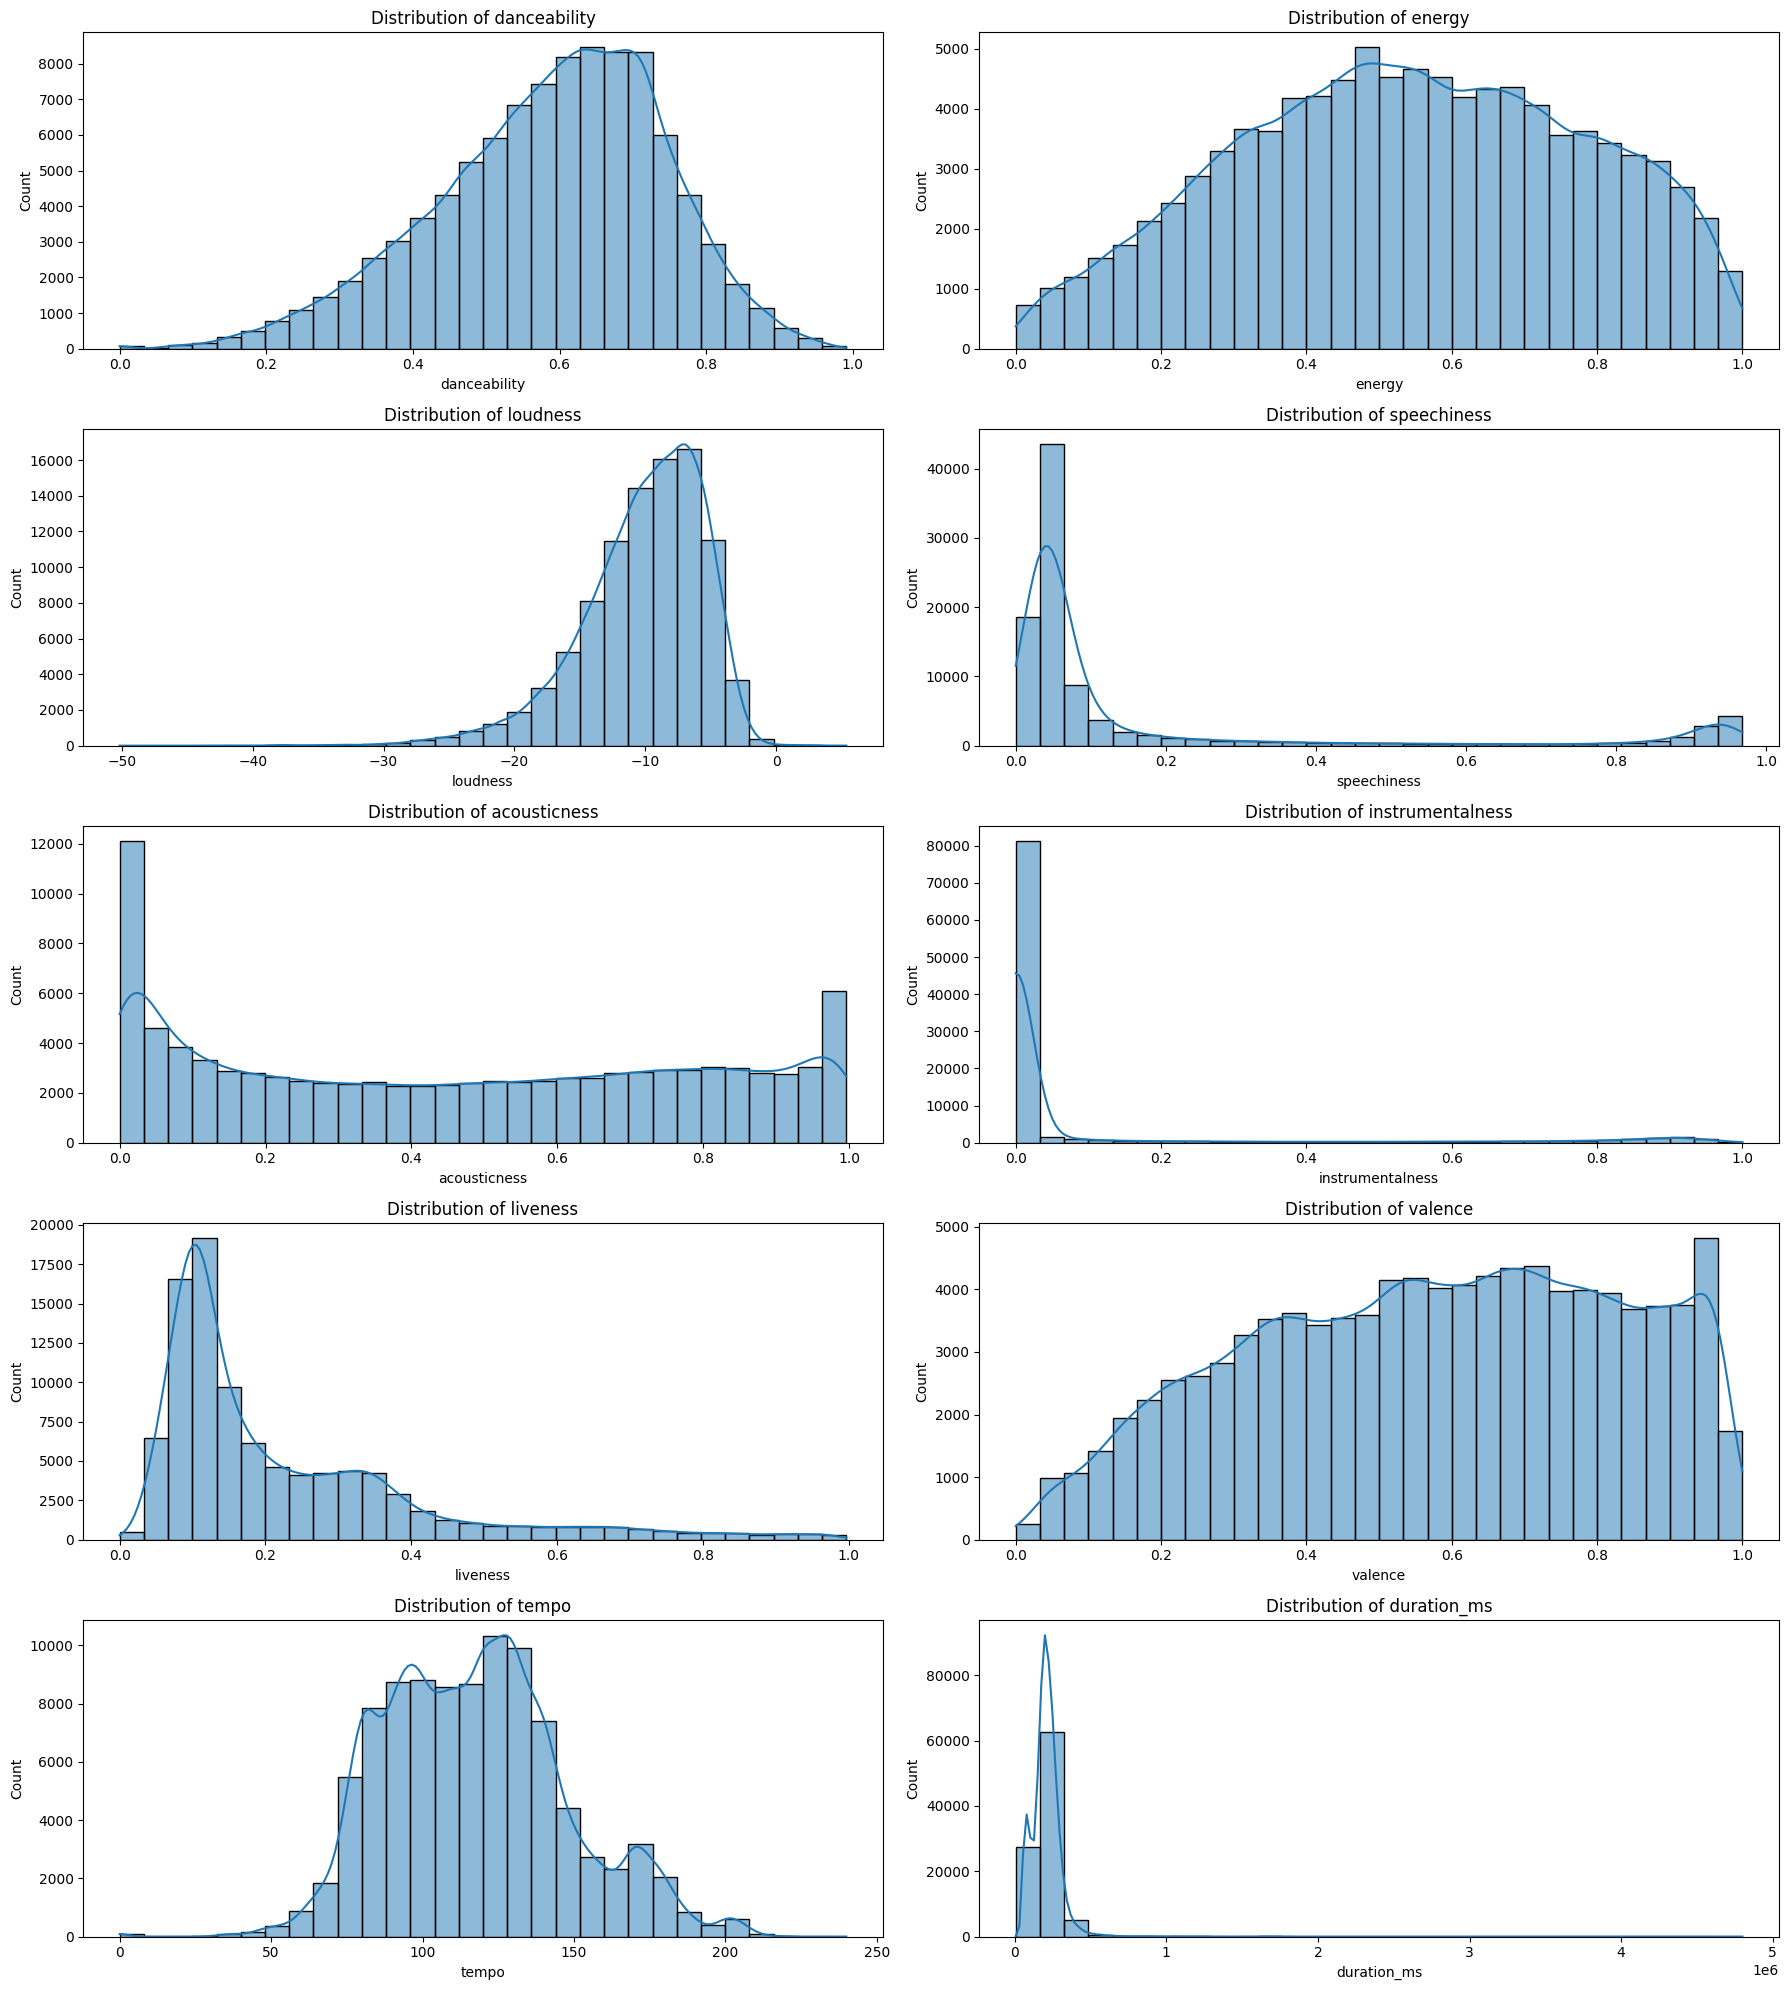

In [199]:
# -------------------------------------------------------------------------
#Visualize distributions of key features to understand variation in values
# -------------------------------------------------------------------------


audio_features = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo',
    'duration_ms'
]

plt.figure(figsize=(18,20))

for i, col in enumerate(audio_features, 1):

    plt.subplot(5,2,i)

    sns.histplot(
        data=df,
        x=col,
        bins=30,
        kde=True
    )

    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

In [210]:
# -----------------
#Feature Selection
# -----------------

features = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo'
]

X = df[features]
print(X.shape)
X.head()

(95837, 9)


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,0.563,0.184,-13.757,0.0512,0.993,0.000016,0.325,0.654,133.088
1,0.427,0.180,-15.375,0.0670,0.989,0.000000,0.128,0.431,78.459
2,0.511,0.206,-15.514,0.0592,0.995,0.000000,0.418,0.481,70.443
3,0.676,0.467,-12.393,0.1650,0.991,0.000000,0.219,0.726,129.775
4,0.650,0.298,-13.806,0.1380,0.991,0.000000,0.373,0.844,75.950


In [211]:
# --------------------------
# Feature Scaling
# --------------------------

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Scale the selected features
X_scaled = scaler.fit_transform(X)



In [ ]:
# Convert the scaled data into a DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=features)

# Verify the scaling
print("Mean:\n", X_scaled.mean().round(2))
print("\nStandard Deviation:\n", X_scaled.std().round(2))

X_scaled.head()

In [ ]:
# ---------------------------------------------
# Elbow Method - Finding the Optimal Number of Clusters
# ---------------------------------------------

from sklearn.cluster import KMeans

wcss = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    # Fit the model
    kmeans.fit(X_scaled)

    # Store WCSS (Inertia)
    wcss.append(kmeans.inertia_)

# Summary table
elbow_table = pd.DataFrame({
    "K": k_values,
    "WCSS": wcss
})

elbow_table["WCSS_Reduction_%"] = (
    elbow_table["WCSS"]
    .pct_change() * -100
).round(2)

elbow_table


,K,WCSS,WCSS_Reduction_%
0,2,685950.965719,NaN
1,3,573286.787436,16.42
2,4,507958.113504,11.40
3,5,464185.948260,8.62
4,6,437304.107543,5.79
5,7,411371.558743,5.93
6,8,387592.119506,5.78
7,9,366813.543026,5.36
8,10,353306.276725,3.68


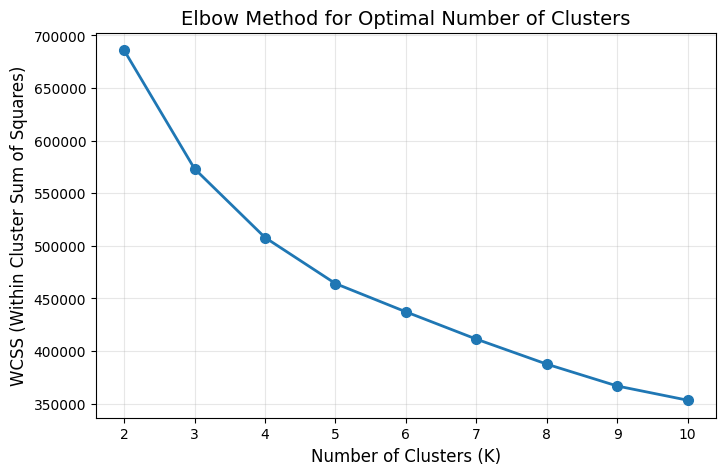

In [ ]:
# Ploting Elbow Curve
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    wcss,
    marker='o',
    linewidth=2,
    markersize=7
)

plt.title("Elbow Method for Optimal Number of Clusters", fontsize=14)
plt.xlabel("Number of Clusters (K)", fontsize=12)
plt.ylabel("WCSS (Within Cluster Sum of Squares)", fontsize=12)

plt.xticks(k_values)
plt.grid(alpha=0.3)

plt.show()

In [154]:
# ---------------------------------------------
# Silhouette Score Analysis
# ---------------------------------------------

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Store Silhouette Scores
silhouette_scores = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    # Compute Silhouette Score
    score = silhouette_score(
        X_scaled,
        labels
    )

    # Store score
    silhouette_scores.append(score)

# ---------------------------------------------
# Create Summary Table
# ---------------------------------------------

silhouette_df = pd.DataFrame({
    "K": k_values,
    "Silhouette Score": silhouette_scores
})

silhouette_df["Silhouette Score"] = (
    silhouette_df["Silhouette Score"]
    .round(4)
)

silhouette_df

,K,Silhouette Score
0,2,0.2102
1,3,0.2494
2,4,0.2394
3,5,0.1960
4,6,0.1691
5,7,0.1751
6,8,0.1828
7,9,0.1828
8,10,0.1749


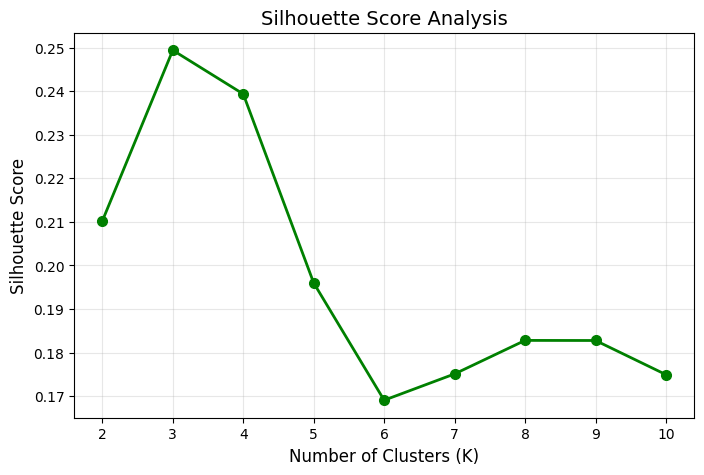

In [155]:
# ---------------------------------------------
# Silhouette Score Plot
# ---------------------------------------------

plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    silhouette_scores,
    marker='o',
    linewidth=2,
    markersize=7,
    color='green'
)

plt.title("Silhouette Score Analysis", fontsize=14)
plt.xlabel("Number of Clusters (K)", fontsize=12)
plt.ylabel("Silhouette Score", fontsize=12)

plt.xticks(k_values)
plt.grid(alpha=0.3)

plt.show()

In [157]:
# ---------------------------------------------
# Davies-Bouldin Index Analysis
# ---------------------------------------------

from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score


dbi_scores = []
k_values = range(2, 11)


for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    # Calculate Davies-Bouldin Index
    dbi = davies_bouldin_score(X_scaled, labels)

    dbi_scores.append(dbi)

# ---------------------------------------------
# Create Summary Table
# ---------------------------------------------

dbi_df = pd.DataFrame({
    "K": k_values,
    "Davies-Bouldin Index": dbi_scores
})

# Round values
dbi_df["Davies-Bouldin Index"] = (
    dbi_df["Davies-Bouldin Index"]
    .round(4)
)

dbi_df

,K,Davies-Bouldin Index
0,2,1.8692
1,3,1.5169
2,4,1.4638
3,5,1.6164
4,6,1.6251
5,7,1.5432
6,8,1.5102
7,9,1.4526
8,10,1.4732


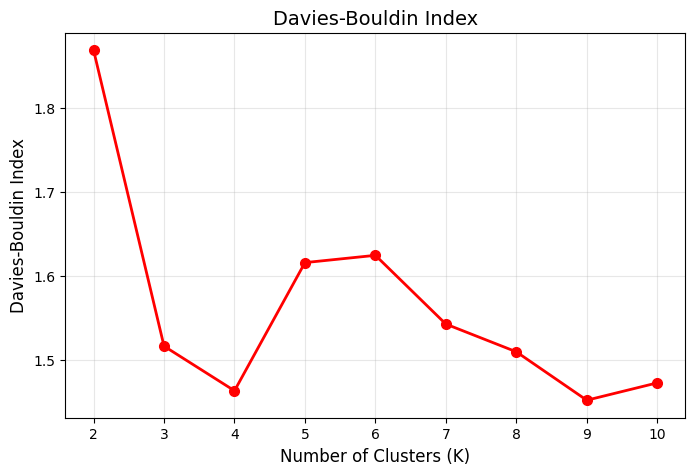

In [ ]:
# ---------------------------------------------
# DBI Score Plot
# ---------------------------------------------

plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    dbi_scores,
    marker='o',
    linewidth=2,
    markersize=7,
    color='red'
)

plt.title("Davies-Bouldin Index", fontsize=14)
plt.xlabel("Number of Clusters (K)", fontsize=12)
plt.ylabel("Davies-Bouldin Index", fontsize=12)

plt.xticks(k_values)
plt.grid(alpha=0.3)

plt.show()

In [ ]:
# ---------------------------------------------------
# Cluster Evaluation Summary
# ---------------------------------------------------

evaluation = (
    elbow_table
    .merge(silhouette_df, on="K")
    .merge(dbi_df, on="K")
)

# ---------------------------------------------------
# Handle missing value in WCSS Reduction %
# ---------------------------------------------------

evaluation["WCSS_Reduction_%"] = (
    evaluation["WCSS_Reduction_%"]
    .fillna(-1)
)

# ---------------------------------------------------
# Rank each evaluation metric
# ---------------------------------------------------

# Higher Silhouette Score = Better
evaluation["Silhouette_Rank"] = (
    evaluation["Silhouette Score"]
    .rank(ascending=False, method="min")
    .astype(int)
)

# Lower Davies-Bouldin Index = Better
evaluation["DBI_Rank"] = (
    evaluation["Davies-Bouldin Index"]
    .rank(ascending=True, method="min")
    .astype(int)
)

# Higher WCSS Reduction = Better
evaluation["Elbow_Rank"] = (
    evaluation["WCSS_Reduction_%"]
    .rank(ascending=False, method="min")
    .astype(int)
)

# ---------------------------------------------------
# Calculating Overall Rank
# ---------------------------------------------------

evaluation["Overall_Rank"] = (
      evaluation["Silhouette_Rank"]
    + evaluation["DBI_Rank"]
    + evaluation["Elbow_Rank"]
)

# Sort by Overall Rank
evaluation = evaluation.sort_values("Overall_Rank")

# Reset Index
evaluation.reset_index(drop=True, inplace=True)

# ---------------------------------------------------
# Recommended K
# ---------------------------------------------------

recommended_k = int(evaluation.loc[0, "K"])

print(f"Recommended Number of Clusters (K): {recommended_k}")

# Final Evaluation Table
evaluation

Recommended Number of Clusters (K): 4


,K,WCSS,WCSS_Reduction_%,Silhouette Score,Davies-Bouldin Index,Silhouette_Rank,DBI_Rank,Elbow_Rank,Overall_Rank
0,4,507958.113504,11.40,0.2394,1.4638,2,2,2,6
1,3,573286.787436,16.42,0.2494,1.5169,1,5,1,7
2,9,366813.543026,5.36,0.1828,1.4526,5,1,7,13
3,5,464185.948260,8.62,0.1960,1.6164,4,7,3,14
4,8,387592.119506,5.78,0.1828,1.5102,5,4,6,15
5,7,411371.558743,5.93,0.1751,1.5432,7,6,4,17
6,10,353306.276725,3.68,0.1749,1.4732,8,3,8,19
7,2,685950.965719,-1.00,0.2102,1.8692,3,9,9,21
8,6,437304.107543,5.79,0.1691,1.6251,9,8,5,22


In [173]:
# ---------------------------------------------------------
# K-Means Clustering (K = 3)
# ---------------------------------------------------------

from sklearn.cluster import KMeans
import pandas as pd

# Initialize and train K-Means
kmeans_3 = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# Generate cluster labels
labels_3 = kmeans_3.fit_predict(X_scaled)

# Create clustered dataset using original (unscaled) features
cluster_3 = X.copy()
cluster_3["Cluster"] = labels_3

# ---------------------------------------------------------
# Cluster Summary
# ---------------------------------------------------------

cluster_summary_3 = pd.DataFrame({
    "Song Count": (
        cluster_3["Cluster"]
        .value_counts()
        .sort_index()
    ),
    "Percentage (%)": (
        cluster_3["Cluster"]
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    )
})

print("Cluster Summary")
display(cluster_summary_3)

# ---------------------------------------------------------
# Cluster Profile
# ---------------------------------------------------------

cluster_profile_3 = (
    cluster_3
    .groupby("Cluster")
    .mean()
    .round(3)
)

print("Cluster Profile")
display(cluster_profile_3)

Cluster Summary


,Song Count,Percentage (%)
Cluster,,
0,52547,54.83
1,12598,13.15
2,30692,32.03


Cluster Profile


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
Cluster,,,,,,,,,
0,0.628,0.694,-7.608,0.076,0.258,0.051,0.200,0.667,124.927
1,0.663,0.464,-13.448,0.830,0.591,0.002,0.441,0.582,100.117
2,0.486,0.311,-13.173,0.057,0.748,0.169,0.179,0.413,112.044


In [174]:
# ---------------------------------------------------------
# K-Means Clustering (K = 4)
# ---------------------------------------------------------

from sklearn.cluster import KMeans
import pandas as pd

# Initialize and train K-Means
kmeans_4 = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

# Generate cluster labels
labels_4 = kmeans_4.fit_predict(X_scaled)

# Create clustered dataset using original (unscaled) features
cluster_4 = X.copy()
cluster_4["Cluster"] = labels_4

# ---------------------------------------------------------
# Cluster Summary
# ---------------------------------------------------------

cluster_summary_4 = pd.DataFrame({
    "Song Count": (
        cluster_4["Cluster"]
        .value_counts()
        .sort_index()
    ),
    "Percentage (%)": (
        cluster_4["Cluster"]
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    )
})

print("Cluster Summary")
display(cluster_summary_4)

# ---------------------------------------------------------
# Cluster Profile
# ---------------------------------------------------------

cluster_profile_4 = (
    cluster_4
    .groupby("Cluster")
    .mean()
    .round(3)
)

print("Cluster Profile")
display(cluster_profile_4)

Cluster Summary


,Song Count,Percentage (%)
Cluster,,
0,29173,30.44
1,46343,48.36
2,12474,13.02
3,7847,8.19


Cluster Profile


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
Cluster,,,,,,,,,
0,0.505,0.343,-12.077,0.058,0.697,0.018,0.180,0.427,113.585
1,0.635,0.708,-7.414,0.078,0.242,0.021,0.201,0.686,125.297
2,0.664,0.465,-13.466,0.835,0.591,0.001,0.441,0.581,100.038
3,0.485,0.415,-13.969,0.060,0.648,0.811,0.189,0.450,114.252


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2']
)

pca_df['Cluster'] = labels_4

df['Cluster'] = labels_4

df.head()

In [ ]:
# ---------------------------------------------------------
# Principal Component Analysis (PCA)
# Reduce the data to 2 dimensions for visualization
# ---------------------------------------------------------

from sklearn.decomposition import PCA

# Initialize PCA
pca = PCA(n_components=2, random_state=42)

# Transform the scaled data
X_pca = pca.fit_transform(X_scaled)

# Create PCA DataFrame
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])

# Add cluster labels
pca_df["Cluster"] = labels_4

# Add cluster labels to the original dataset
df["Cluster"] = labels_4

# Display first few rows
pca_df.head()

,PC1,PC2,Cluster
0,-1.640235,0.193896,0
1,-2.668771,-0.273729,0
2,-2.527451,0.743589,0
3,-0.624921,0.575651,0
4,-1.411232,1.503020,0


In [178]:
# ---------------------------------------------------------
# Display Sample Songs from Each Cluster
# ---------------------------------------------------------

for cluster in sorted(df["Cluster"].unique()):

    print("=" * 70)
    print(f"Cluster {cluster}")
    print("=" * 70)

    display(
        df.loc[df["Cluster"] == cluster,
               ["name_song", "name_artists", "genres"]]
        .sample(10, random_state=42)
        .reset_index(drop=True)
    )

Cluster 0


,name_song,name_artists,genres
0,Kendim Ettim Kendim Buldum,Erkin Koray,['anadolu rock']
1,Dame Un Silbidito,Pablo Palos,['disney espanol']
2,Begonvil,Sezen Aksu,['turkish pop']
3,Kaks Kuukiirt Mu Toas,Marju Kuut,[]
4,Unos Versos,Salta La Banca,['argentine rock']
5,Taguan,John Roa,['opm']
6,In the Pines,The Kossoy Sisters,['appalachian folk']
7,Revelação,Fagner,['mpb']
8,Die Forelle,Jules de Corte,['vintage dutch pop']
9,Ædni Mánná,Tanabreddens Ungdom,['sami']


Cluster 1


,name_song,name_artists,genres
0,SOULS(Main),bird,['japanese jazztronica']
1,トマト・イッパツ Tomato Ippatsu,Spectrum,['classic city pop']
2,Mézga Géza,Hot Jazz Band,['hungarian folk']
3,Panama Kanaal,Rudi Carrell,['classic schlager']
4,Inbjudan till Bohuslän,Öbarna,['vintage swedish pop']
5,Boy,Todd,['rap francais']
6,Knock Knock,SoFaygo,['vapor trap']
7,Big Brother,Blind Zero,['portuguese rock']
8,Udlalelani Na?,Derrick Ndzimande,['south african gospel']
9,It was midnight on the ocean,The Tune Wranglers,['western swing']


Cluster 2


,name_song,name_artists,genres
0,Gungorna och karusellen,Karl Gerhard,['vintage swedish pop']
1,Kapitel 40 - im Krankenhaus (Folge 013),Benjamin Blümchen,['hoerspiel']
2,Kapitel 40 - ist krank (Folge 054),Benjamin Blümchen,['hoerspiel']
3,L'oiseau et la bulle,Pierre Chêne,['musique pour enfants']
4,Kapitel 27 - Papa ist weg (Folge 020),Bibi Blocksberg,['hoerspiel']
5,013 - Die Bettelmönche aus Atlantis - Teil 03,TKKG Retro-Archiv,['kleine hoerspiel']
6,034 - Vampir der Autobahn - Teil 10,TKKG Retro-Archiv,['kleine hoerspiel']
7,Kapitel 40 - reißt aus (Folge 025),Bibi Blocksberg,['hoerspiel']
8,039 - und die Perlenvögel - Teil 03,Die drei ???,['hoerspiel']
9,046 - Hotel in Flammen - Teil 13,TKKG Retro-Archiv,['kleine hoerspiel']


Cluster 3


,name_song,name_artists,genres
0,Calm Rolling Thunder and Soothing Rain,Nature Sounds,"['environmental', 'sleep', 'water']"
1,Svallvågor,Jan Johansson,['swedish jazz']
2,L'Aérogramme De Los Angeles,Yves Simon,['chanson']
3,Young And Foolish,Bill Evans,"['adult standards', 'bebop', 'cool jazz', 'jaz..."
4,Hawaiian Paradise,Les Paul,['space age pop']
5,L'Esperanza - Radio Edit,Airscape,['trance']
6,大きな古時計,オルゴールの世界,['japanese instrumental']
7,If You Don't Want My Love,Gábor Szabó,['spiritual jazz']
8,Marzenie miłosne - paraphrase,Mieczysław Kosz,['polish jazz']
9,Malevisiotikos Horos,Manolis Alexakis,['kritika']


In [179]:
# ---------------------------------------------------------
# Adding Cluster Names
# ---------------------------------------------------------

cluster_names = {
    0: "Acoustic & Melodic Music",
    1: "Energetic & Danceable Music",
    2: "Speech & Narration Audio",
    3: "Instrumental & Ambient Music"
}

pca_df["Cluster_Name"] = pca_df["Cluster"].map(cluster_names)

df["Cluster_Name"] = df["Cluster"].map(cluster_names)

df.head()

,id_songs,name_song,popularity_songs,duration_ms,explicit,id_artists,release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,genres,name_artists,popularity_artists,Cluster,Cluster_Name
0,0IA0Hju8CAgYfV1hwhidBH,La Java,0,161427,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.563,0.184,4,-13.757,1,0.0512,0.993,0.000016,0.325,0.654,133.088,3,5078.0,['vintage chanson'],Mistinguett,22,0,Acoustic & Melodic Music
1,1b8HZQCqcqwbzlA1jRTp6E,En Douce,0,223440,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.427,0.180,10,-15.375,1,0.0670,0.989,0.000000,0.128,0.431,78.459,3,5078.0,['vintage chanson'],Mistinguett,22,0,Acoustic & Melodic Music
2,5d5gQxHwYovxR5pqETOIAa,J'en Ai Marre,0,208267,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.511,0.206,0,-15.514,1,0.0592,0.995,0.000000,0.418,0.481,70.443,4,5078.0,['vintage chanson'],Mistinguett,22,0,Acoustic & Melodic Music
3,1EO65UEEPfy7CR0NK2sDxy,Ils n'ont pas ca,0,161933,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.676,0.467,9,-12.393,0,0.1650,0.991,0.000000,0.219,0.726,129.775,4,5078.0,['vintage chanson'],Mistinguett,22,0,Acoustic & Melodic Music
4,6a58gXSgqbIsXUhVZ6ZJqe,La belote,0,167973,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.650,0.298,9,-13.806,1,0.1380,0.991,0.000000,0.373,0.844,75.950,4,5078.0,['vintage chanson'],Mistinguett,22,0,Acoustic & Melodic Music


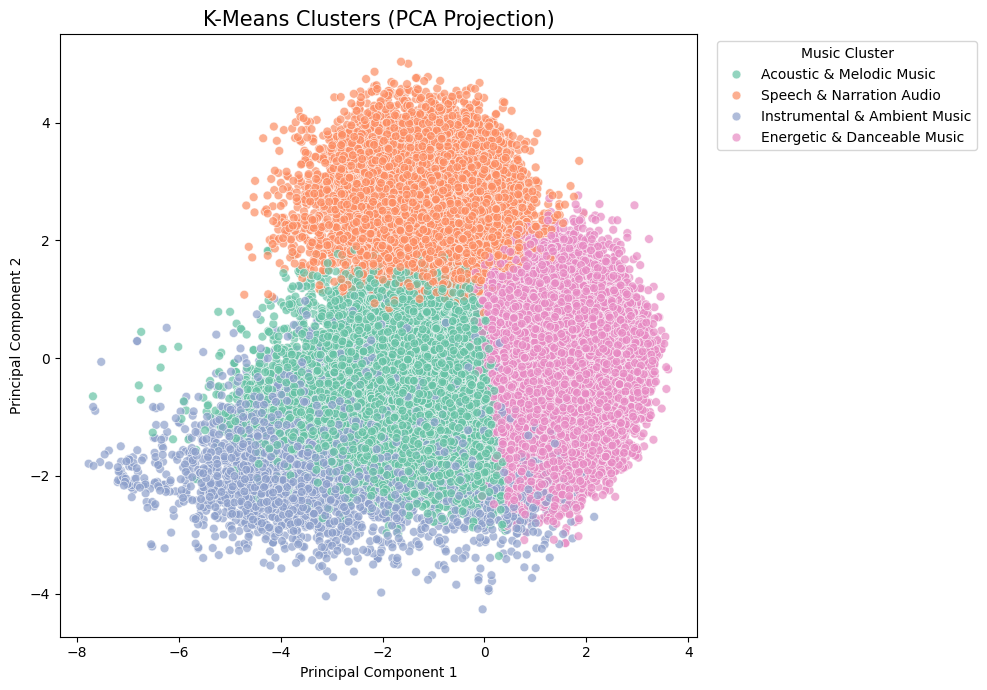

In [ ]:
# ---------------------------------------------------------
#  PCA Visualization of K-Means Clusters
# ---------------------------------------------------------

from sklearn.decomposition import PCA
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster_Name",
    palette="Set2",
    alpha=0.7,
    s=40
)

plt.title("K-Means Clusters (PCA Projection)", fontsize=15)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(title="Music Cluster", bbox_to_anchor=(1.02,1), loc="upper left")

plt.tight_layout()

plt.show()

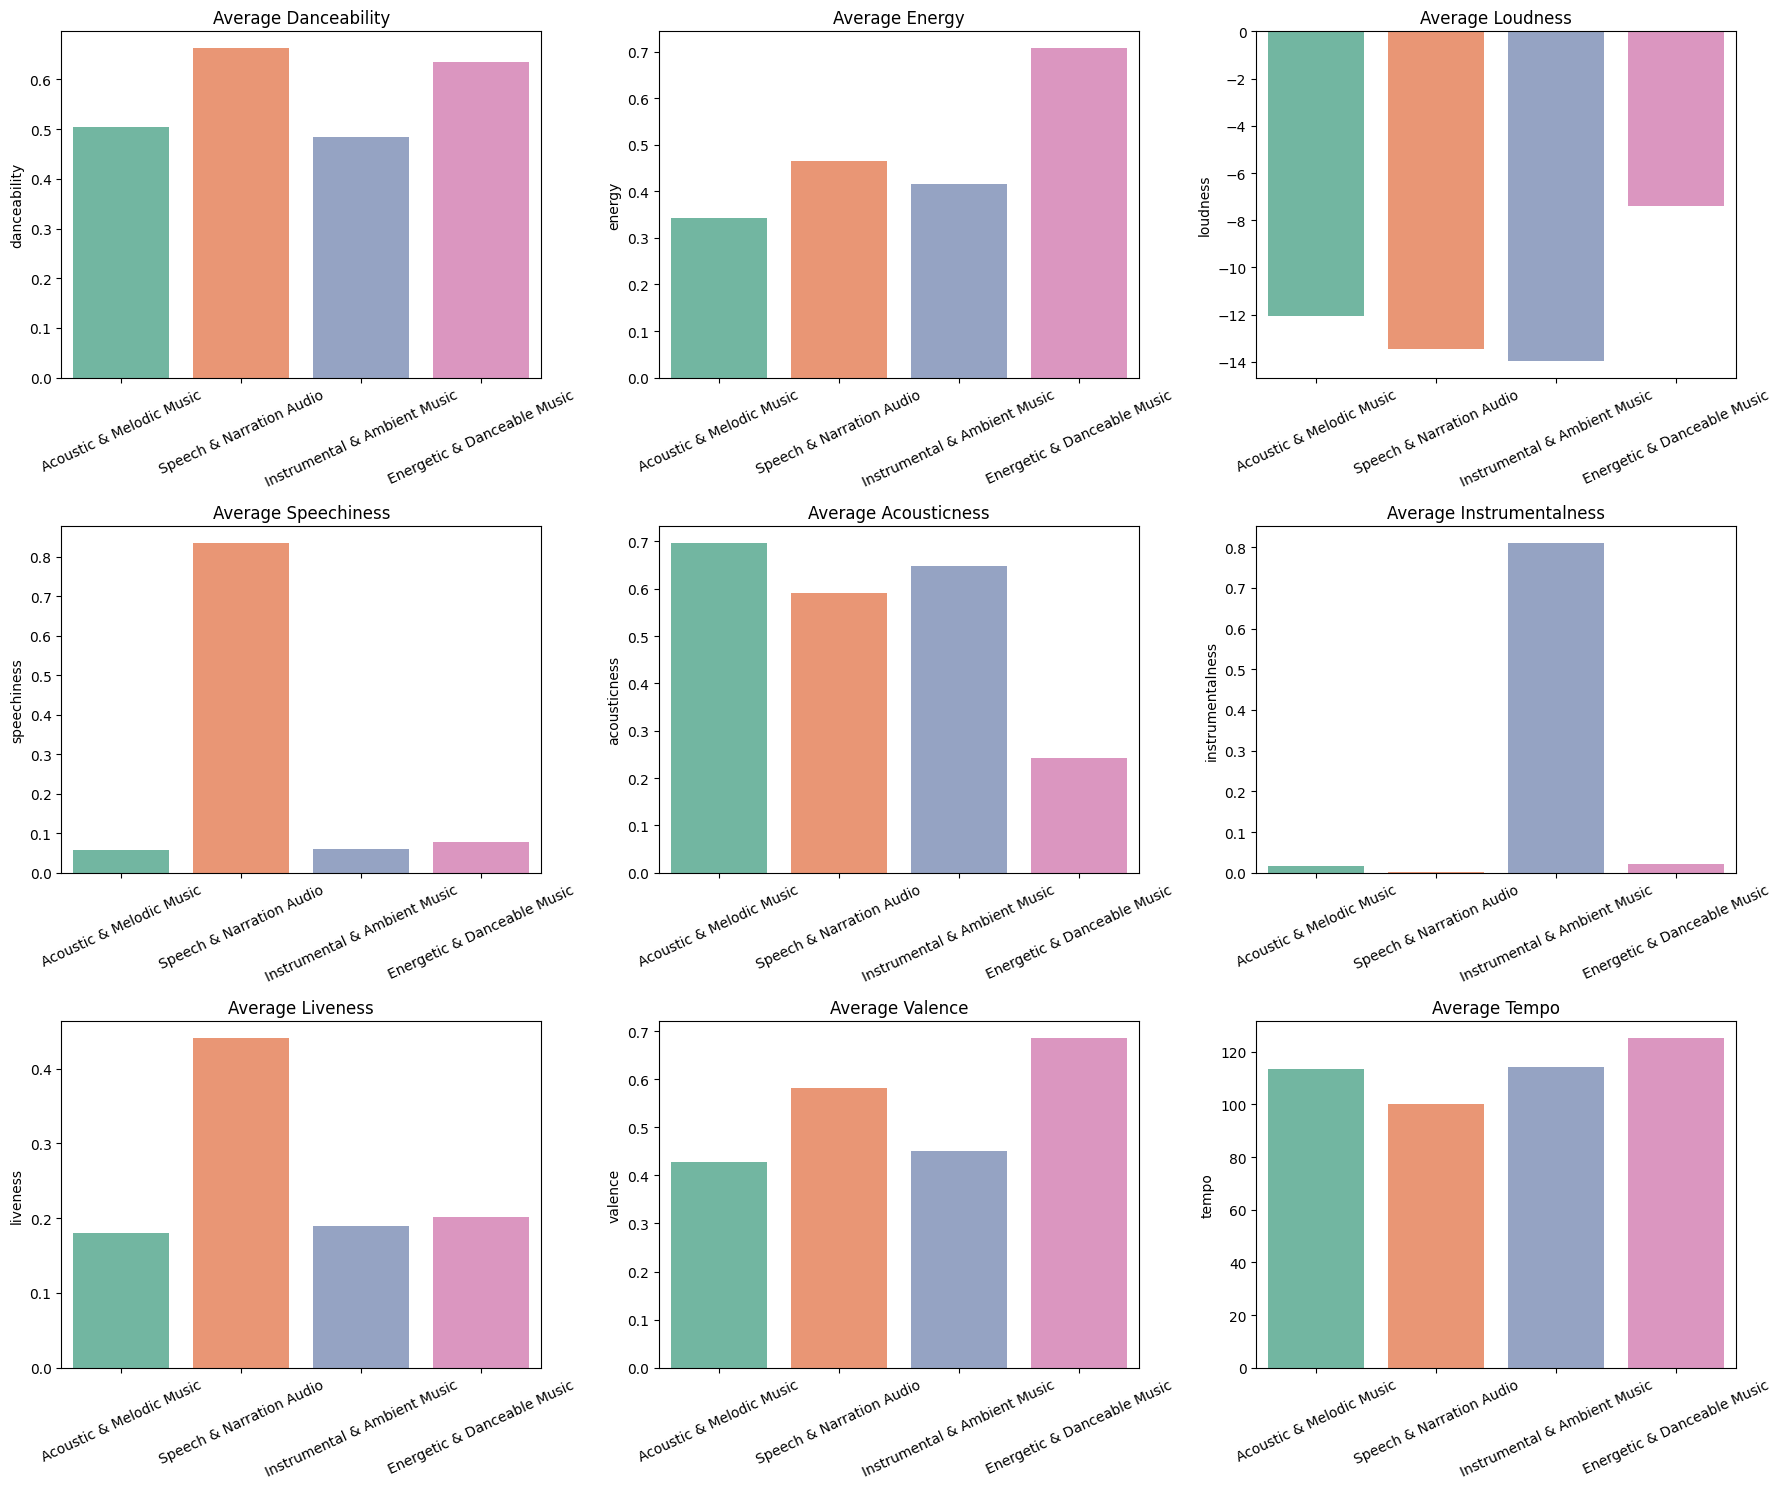

In [181]:
# ----------------------------------------------------------------
#  Bar chart Visualization of average feature values per cluster
# ----------------------------------------------------------------

features = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo'
]

fig, axes = plt.subplots(3,3, figsize=(18,15))

axes = axes.flatten()

for i, feature in enumerate(features):

    sns.barplot(
        data=df,
        x="Cluster_Name",
        y=feature,
        estimator="mean",
        errorbar=None,
        palette="Set2",
        ax=axes[i]
    )

    axes[i].set_title(f"Average {feature.title()}", fontsize=12)

    axes[i].set_xlabel("")

    axes[i].tick_params(axis='x', rotation=25)

plt.tight_layout()

plt.show()

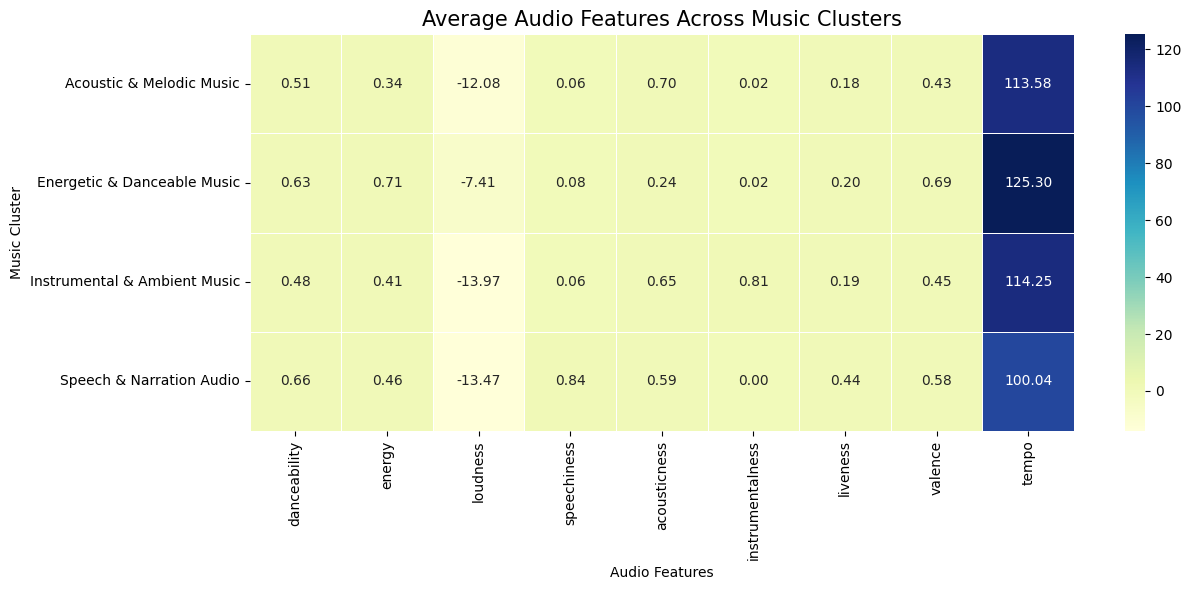

In [182]:
# ----------------------------------------------------------------
#  Heatmap Visualization for comparing features across clusters
# ----------------------------------------------------------------

cluster_profile = df.groupby("Cluster_Name")[
    features
].mean()

plt.figure(figsize=(13,6))

sns.heatmap(
    cluster_profile,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Average Audio Features Across Music Clusters", fontsize=15)

plt.xlabel("Audio Features")
plt.ylabel("Music Cluster")

plt.tight_layout()

plt.show()

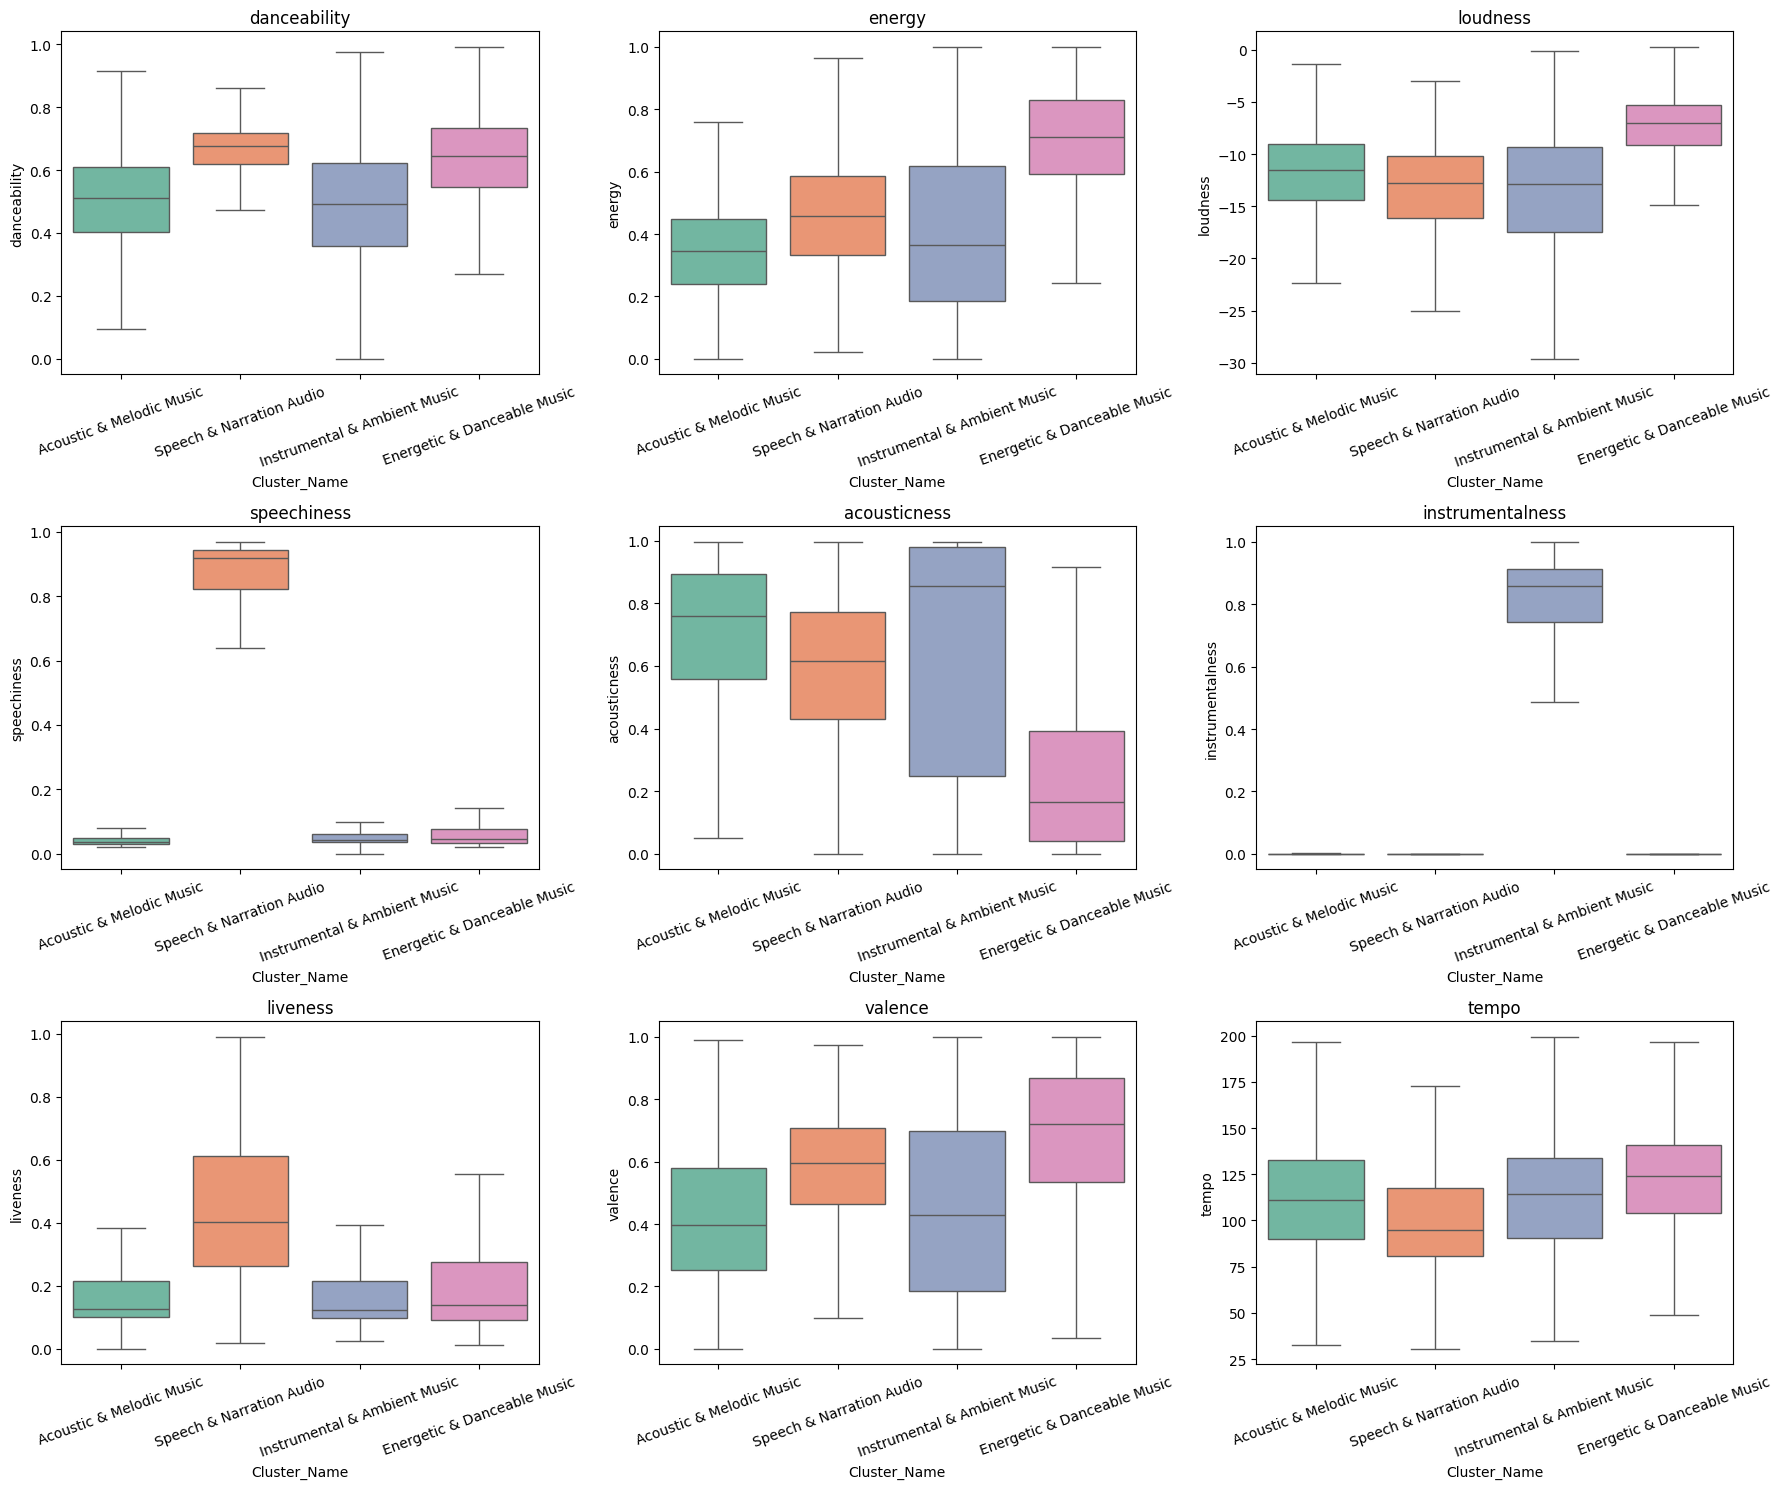

In [183]:
# ---------------------------------------------------------------------
# Boxplot visualization for Feature Distribution Across Music Clusters
# ---------------------------------------------------------------------

features = [
    'danceability','energy','loudness','speechiness',
    'acousticness','instrumentalness','liveness',
    'valence','tempo'
]

fig, axes = plt.subplots(3, 3, figsize=(18, 15))

axes = axes.flatten()

for i, feature in enumerate(features):

    sns.boxplot(
        data=df,
        x='Cluster_Name',
        y=feature,
        palette='Set2',
        showfliers=False,
        ax=axes[i]
    )

    axes[i].set_title(feature, fontsize=12)
    axes[i].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

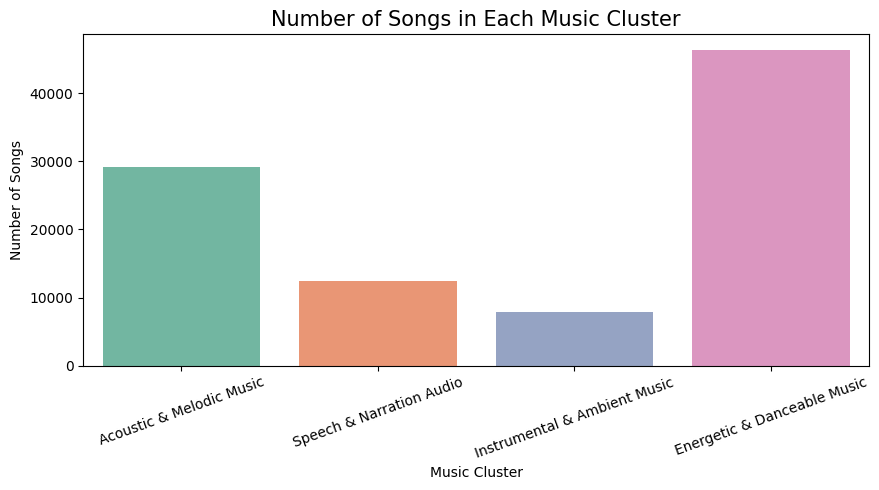

In [184]:
# ---------------------------------------------------------------------
# Bar chart visualization for Number of Songs in Each Music Cluster
# ---------------------------------------------------------------------

plt.figure(figsize=(9,5))

sns.countplot(
    data=df,
    x="Cluster_Name",
    palette="Set2"
)

plt.title("Number of Songs in Each Music Cluster", fontsize=15)

plt.xlabel("Music Cluster")
plt.ylabel("Number of Songs")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

In [186]:
# ---------------------------------------------------------
# Top 10 Most Popular Songs from Each Cluster
# ---------------------------------------------------------

for cluster in sorted(df["Cluster"].unique()):

    print("=" * 80)
    print(f"{df[df['Cluster']==cluster]['Cluster_Name'].iloc[0]}")
    print("=" * 80)

    display(
        df[df["Cluster"] == cluster]
        .sort_values(
            by="popularity_songs",
            ascending=False
        )[
            [
                "name_song",
                "name_artists",
                "popularity_songs"
            ]
        ]
        .head(10)
        .reset_index(drop=True)
    )

Acoustic & Melodic Music


,name_song,name_artists,popularity_songs
0,What You Know Bout Love,Pop Smoke,91
1,Arcade,Duncan Laurence,89
2,Put Your Records On,Ritt Momney,87
3,Arcade,Duncan Laurence,83
4,Hold On,Chord Overstreet,83
5,Party Girl,StaySolidRocky,81
6,Beautiful Crazy,Luke Combs,80
7,Control,Zoe Wees,80
8,Go Fuck Yourself,Two Feet,80
9,agoraphobic,CORPSE,79


Energetic & Danceable Music


,name_song,name_artists,popularity_songs
0,Astronaut In The Ocean,Masked Wolf,98
1,WITHOUT YOU,The Kid LAROI,94
2,Hecha Pa' Mi,Boza,92
3,911,Sech,91
4,Goosebumps,HVME,89
5,Whoopty,CJ,89
6,RAPSTAR,Polo G,89
7,Martin & Gina,Polo G,88
8,Tapão Na Raba,Raí Saia Rodada,87
9,Hayloft,Mother Mother,86


Speech & Narration Audio


,name_song,name_artists,popularity_songs
0,Siempre Fine,Ak4:20,72
1,Beautiful Pain (Losin My Mind),Polo G,72
2,Gentleman,SL,70
3,The Chicken Wing Beat,Ricky Desktop,70
4,Neva Cared,Polo G,70
5,Ain't Nobody Takin My Baby,Russ,69
6,Lo jodiste,Babi,66
7,VIP in der Psychiatrie,K.I.Z,65
8,You Reposted in the Wrong Neighborhood I Glue7...,Shokk,63
9,Ella Se Arrebata,Ak4:20,63


Instrumental & Ambient Music


,name_song,name_artists,popularity_songs
0,ROLLIN N CONTROLLIN FREESTYLE,DUSTY LOCANE,83
1,YKWIM?,Yot Club,79
2,Jealous,Eyedress,78
3,Buttercup,Jack Stauber,78
4,Jealous,Eyedress,77
5,Soft Brown Noise,High Altitude Samples,76
6,Friendships,Pascal Letoublon,75
7,Show Me How,Men I Trust,75
8,Brahms Lullaby,Beth McLaughlin,74
9,Snowman,WYS,74


In [187]:
# ---------------------------------------------------------
# Exporting Final Dataset
# ---------------------------------------------------------

df.to_csv(
    "amazon_music_clustered.csv",
    index=False
)

print("Dataset exported successfully.")

Dataset exported successfully.


In [219]:
# ---------------------------------------------------------
# Save the Trained K-Means Model and StandardScaler
# ---------------------------------------------------------

import joblib

# Save the trained K-Means clustering model
joblib.dump(kmeans_4, "kmeans_model.pkl")

# Save the fitted StandardScaler
joblib.dump(scaler, "std_scaler.pkl")

print("K-Means model and StandardScaler saved successfully.")

K-Means model and StandardScaler saved successfully.
